In [391]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
#import warnings

In [392]:
# Параметры
x_corr = 0.98
remove_highly_correlated_parameters = True

In [393]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl' -O train.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l' -O test.csv

--2026-05-19 18:21:31--  https://drive.google.com/uc?export=download&id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl
Resolving drive.google.com (drive.google.com)... 142.250.141.139, 142.250.141.101, 142.250.141.102, ...
Connecting to drive.google.com (drive.google.com)|142.250.141.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl&export=download [following]
--2026-05-19 18:21:31--  https://drive.usercontent.google.com/download?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.137.132, 2607:f8b0:4023:c03::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.137.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1359909 (1.3M) [application/octet-stream]
Saving to: ‘train.csv’

train.csv           100%[===================>]   1.30M  --.-KB/s 

In [394]:
train = pd.read_csv('train.csv',sep=',', decimal = '.')
test = pd.read_csv('test.csv',sep=',', decimal = '.')

print(train.info())
print()
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB
None


In [395]:
print(train.info(verbose=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 214 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    index                     int64  
 1    IC50, mM                  float64
 2    CC50, mM                  float64
 3    SI                        float64
 4    MaxAbsEStateIndex         float64
 5    MaxEStateIndex            float64
 6    MinAbsEStateIndex         float64
 7    MinEStateIndex            float64
 8    qed                       float64
 9    SPS                       float64
 10   MolWt                     float64
 11   HeavyAtomMolWt            float64
 12   ExactMolWt                float64
 13   NumValenceElectrons       int64  
 14   NumRadicalElectrons       int64  
 15   MaxPartialCharge          float64
 16   MinPartialCharge          float64
 17   MaxAbsPartialCharge       float64
 18   MinAbsPartialCharge       float64
 19   FpDensityMorgan1          float64
 20   FpDensit

In [396]:
target_columns = ['IC50, mM', 'CC50, mM']

# SI - производная IC50, mM и CC50, mM
delete_columns = ['SI']

feature_cols = [c for c in train.columns if c not in target_columns + delete_columns + ['index']]

In [397]:
# Проверяем дубликаты

# Полные дубликаты строк (по всем признакам)
full_dups = train.duplicated(subset=feature_cols, keep=False)
print("=== ПОЛНЫЕ ДУБЛИКАТЫ СТРОК (все признаки совпадают) ===")
print(f"Количество дублированных строк: {full_dups.sum()}")

if full_dups.sum() > 0:
    # Показываем пример дубликата
    dup_example = train[full_dups].sort_values(by=feature_cols[:5]).head(8)
    print("\nПример дубликатов (первые 8 строк):")
    display(dup_example[target_columns + feature_cols[:3]])

    # Проверяем, одинаковые ли у них целевые значения
    print("\n=== ПРОВЕРКА: ОДИНАКОВЫЕ ЛИ ЦЕЛЕВЫЕ У ДУБЛИКАТОВ? ===")
    for col in target_columns:
        # Группируем по всем признакам и смотрим на целевые
        dup_groups = train[full_dups].groupby(feature_cols)[col].agg(['min', 'max', 'std'])
        diff = (dup_groups['max'] - dup_groups['min']).abs()
        print(f"{col}: различаются в { (diff > 1e-6).sum() } из {len(dup_groups)} групп")



=== ПОЛНЫЕ ДУБЛИКАТЫ СТРОК (все признаки совпадают) ===
Количество дублированных строк: 181

Пример дубликатов (первые 8 строк):


,"IC50, mM","CC50, mM",MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex
115,5.099621,100.000452,2.599352,2.599352,0.572338
540,5.998491,100.000452,2.599352,2.599352,0.572338
263,6.000683,100.000000,2.669444,2.669444,0.549375
625,100.000000,100.000000,2.669444,2.669444,0.549375
683,100.000000,100.000000,2.669444,2.669444,0.549375
206,24.466747,79.272261,4.301519,4.301519,0.567685
276,146.800483,133.588440,4.301519,4.301519,0.567685
171,54.087564,257.956073,4.688093,4.688093,0.304538



=== ПРОВЕРКА: ОДИНАКОВЫЕ ЛИ ЦЕЛЕВЫЕ У ДУБЛИКАТОВ? ===
IC50, mM: различаются в 49 из 60 групп
CC50, mM: различаются в 43 из 60 групп


In [398]:
# Агрегируем дубликаты
#warnings.filterwarnings('ignore')
train = train.groupby(feature_cols)[target_columns].median().reset_index()
#warnings.filterwarnings('default')

print(train.shape)

(628, 212)


In [399]:
# Разделяем трейн на X_train и y_train
X_train = train[feature_cols].copy()
y_train = train[target_columns].copy()
X_test = test[feature_cols].copy()

print(f"Размер X_train: {X_train.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер X_test: {X_test.shape}")

Размер X_train: (628, 210)
Размер y_train: (628, 2)
Размер X_test: (250, 210)


In [400]:
# Проверяем пропуски
datasets = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print(f"\n{'='*50}")
    print(f"=== ПРОПУСКИ В {name} ===")
    print(f"{'='*50}")

    if len(missing) == 0:
        print("Пропусков нет")
    else:
        print(f"Колонок с пропусками: {len(missing)}")
        print(f"Максимум пропусков в одной колонке: {missing.max()}")
        print(f"\nТоп-20 колонок с пропусками:")
        print(missing.head(20))


=== ПРОПУСКИ В X_train ===
Пропусков нет

=== ПРОПУСКИ В y_train ===
Пропусков нет

=== ПРОПУСКИ В X_test ===
Колонок с пропусками: 12
Максимум пропусков в одной колонке: 1

Топ-20 колонок с пропусками:
MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64


In [401]:
# ОБРАБОТКА ПРОПУСКОВ
# Создаем импутер, который будет заполнять пропуски медианой
imputer = SimpleImputer(strategy='median')

# Обучаем импутер на трейне
imputer.fit(X_train)

# Применяем к трейну и тесту
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Проверяем, что пропусков не осталось
print("Пропусков в train:", X_train.isnull().sum().sum())
print("Пропусков в test:", X_test.isnull().sum().sum())

Пропусков в train: 0
Пропусков в test: 0


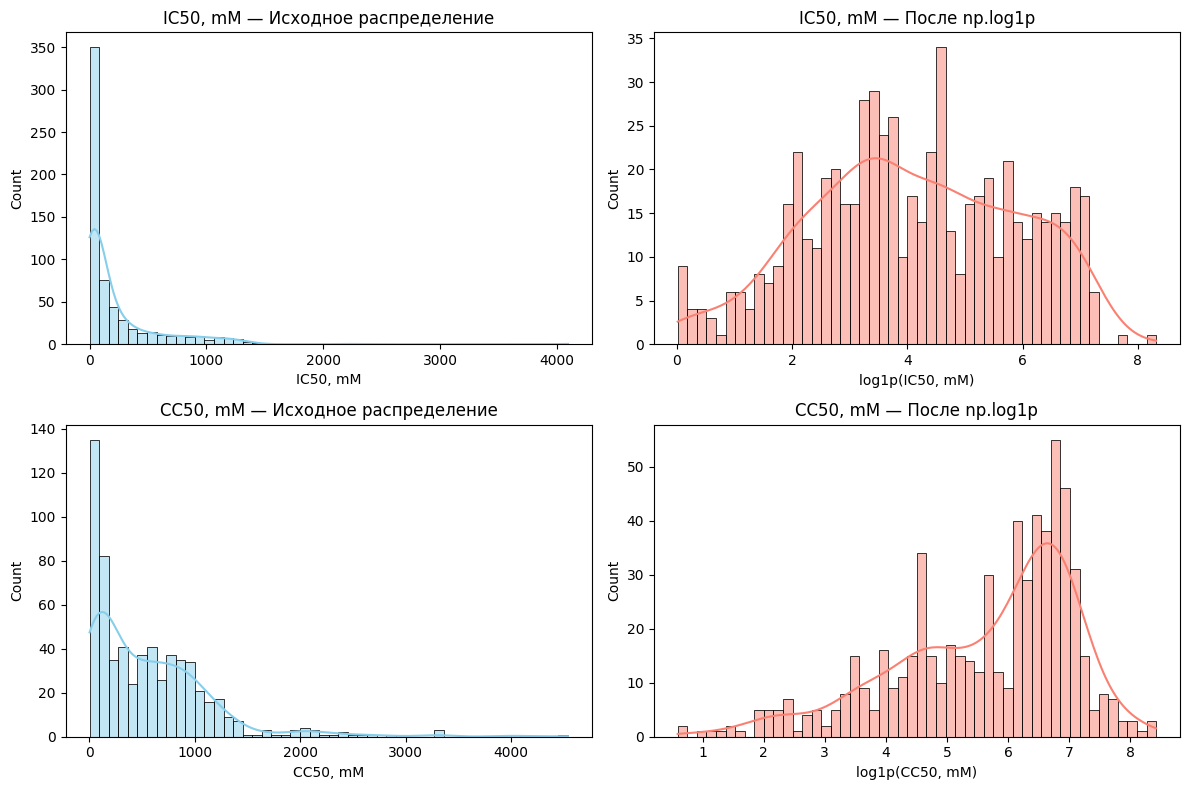

=== СТАТИСТИКА ЦЕЛЕВЫХ ПЕРЕМЕННЫХ ===
          IC50, mM     CC50, mM
count   628.000000   628.000000
mean    216.209140   565.429025
std     359.783260   595.963317
min       0.013341     0.810833
1%        0.102940     3.743291
5%        2.049824    13.402150
25%      15.297880    99.999960
50%      55.989469   447.832221
75%     253.997147   863.946064
95%    1007.303000  1432.671714
99%    1305.989523  2835.004531
max    4095.188563  4538.976189

=== АСИММЕТРИЯ ===
IC50, mM: 3.5289
CC50, mM: 2.2794
=== АСИММЕТРИЯ ПОСЛЕ np.log1p ===
log1p(IC50, mM): -0.0902
log1p(CC50, mM): -0.8775


In [402]:
# Анализ целевых переменных

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(target_columns):
    # Гистограмма исходных данных
    sns.histplot(y_train[col], bins=50, kde=True, ax=axes[i*2], color='skyblue')
    axes[i*2].set_title(f'{col} — Исходное распределение')
    axes[i*2].set_xlabel(col)

    # Гистограмма логарифмированных данных
    # Добавляем 1 для избежания log(0), если такие значения есть
    log_col = np.log1p(y_train[col])
    sns.histplot(log_col, bins=50, kde=True, ax=axes[i*2+1], color='salmon')
    axes[i*2+1].set_title(f'{col} — После np.log1p')
    axes[i*2+1].set_xlabel(f'log1p({col})')

plt.tight_layout()
plt.show()

# Статистики для анализа
print("=== СТАТИСТИКА ЦЕЛЕВЫХ ПЕРЕМЕННЫХ ===")
print(y_train.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

print("\n=== АСИММЕТРИЯ ===")
print(f"IC50, mM: {y_train['IC50, mM'].skew():.4f}")
print(f"CC50, mM: {y_train['CC50, mM'].skew():.4f}")

y_train_log = np.log1p(y_train)

# Сравним асимметрию после преобразования
print("=== АСИММЕТРИЯ ПОСЛЕ np.log1p ===")
print(f"log1p(IC50, mM): {y_train_log['IC50, mM'].skew():.4f}")
print(f"log1p(CC50, mM): {y_train_log['CC50, mM'].skew():.4f}")

Распределение сильно скошено вправо по обоим целевым показателям. Будем использовать в логарифмическом масштабе.

In [403]:
# Поиск и удаление константных признаков
# Находим признаки с нулевой дисперсией
constant_filter = VarianceThreshold(threshold=0)
constant_filter.fit(X_train)

# Маска: True для признаков, которые остаются
keep_mask  = constant_filter.get_support()

remove_mask = ~keep_mask

# Список удалённых признаков
print(f'Удалено колонок {len(X_train.columns[remove_mask].tolist())}')

# Применяем фильтрацию
X_train = X_train.loc[:, keep_mask]
X_test = X_test.loc[:, keep_mask]

print(f"\nРазмер X_train после удаления констант: {X_train.shape}")
print(f"Размер X_test после удаления констант: {X_test.shape}")

Удалено колонок 18

Размер X_train после удаления констант: (628, 192)
Размер X_test после удаления констант: (250, 192)


Обнаружены константные параметры (все значения в полях равны).
Всего 18 колонок. Удаляем.

In [404]:
# Масштабирование признаков

# Анализ разброса признаков до масштабирования
print("=== Разброс признаков до масштабирования ===")
min_vals = X_train.min()
max_vals = X_train.max()
range_df = pd.DataFrame({'Min': min_vals, 'Max': max_vals, 'Range': max_vals - min_vals})


print(f"\nКоличество бинарных признаков: {sum( (X_train.nunique() == 2) & (X_train.isin([0,1]).all()) )}")
print(f"Общее количество признаков: {X_train.shape[1]}")

# Создаем скейлер
scaler = StandardScaler()

# Обучаем на трейне
scaler.fit(X_train)

# Применяем к трейну и тесту
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Анализ после масштабирования
print("\n=== После масштабирования ===")
print("Средние:")
print(X_train_scaled.mean().describe())
print("\nСтандартные отклонения:")
print(X_train_scaled.std().describe())

=== Разброс признаков до масштабирования ===

Количество бинарных признаков: 31
Общее количество признаков: 192

=== После масштабирования ===
Средние:
count    1.920000e+02
mean     1.733250e-17
std      1.781700e-16
min     -7.410915e-16
25%     -4.525750e-17
50%      0.000000e+00
75%      4.667180e-17
max      1.040922e-15
dtype: float64

Стандартные отклонения:
count    1.920000e+02
mean     1.000797e+00
std      3.928042e-15
min      1.000797e+00
25%      1.000797e+00
50%      1.000797e+00
75%      1.000797e+00
max      1.000797e+00
dtype: float64


In [405]:
# === КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===
corr_matrix = X_train_scaled.corr().abs()

# Находим пары с корреляцией > x_corr
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > x_corr:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\n=== ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > {x_corr} ===")
print(f"Всего таких пар: {len(high_corr_pairs)}")
if high_corr_pairs:
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)[:100]:
        print(f"  {f1} — {f2}: {corr:.4f}")


=== ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.98 ===
Всего таких пар: 46
  MaxAbsEStateIndex — MaxEStateIndex: 1.0000
  NumAromaticCarbocycles — fr_benzene: 1.0000
  fr_Ar_NH — fr_Nhpyrrole: 1.0000
  fr_COO — fr_COO2: 1.0000
  fr_nitro_arom — fr_nitro_arom_nonortho: 1.0000
  fr_phenol — fr_phenol_noOrthoHbond: 1.0000
  MolWt — ExactMolWt: 1.0000
  Chi1 — HeavyAtomCount: 0.9987
  MolWt — HeavyAtomMolWt: 0.9971
  HeavyAtomMolWt — ExactMolWt: 0.9971
  Chi0 — HeavyAtomCount: 0.9959
  NumValenceElectrons — Chi0: 0.9949
  LabuteASA — HeavyAtomCount: 0.9944
  Chi1 — LabuteASA: 0.9931
  Chi0n — Chi0v: 0.9920
  NumValenceElectrons — HeavyAtomCount: 0.9907
  Chi0 — Chi1: 0.9905
  NumValenceElectrons — LabuteASA: 0.9899
  Chi0n — Chi1n: 0.9897
  fr_Ar_OH — fr_phenol: 0.9894
  fr_Ar_OH — fr_phenol_noOrthoHbond: 0.9894
  Chi0 — LabuteASA: 0.9892
  NHOHCount — NumHDonors: 0.9889
  Chi0v — MolMR: 0.9885
  Chi0v — Chi1v: 0.9884
  ExactMolWt — HeavyAtomCount: 0.9880
  MolWt — HeavyAtomCount: 0.9879
  ExactMolW

In [406]:
# === УДАЛЕНИЕ ВЫСОКОКОРРЕЛИРОВАННЫХ ПРИЗНАКОВ ===
if remove_highly_correlated_parameters:
    def remove_highly_correlated(X, threshold):
        """
        Удаляет признаки с корреляцией выше threshold.
        Из каждой пары удаляется тот, у которого МЕНЬШЕ корреляция с целевой переменной.
        Если цели нет — удаляется второй по порядку.
        """
        corr_matrix = X.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # Находим пары для удаления
        to_drop = set()
        for col in upper_triangle.columns:
            if col in to_drop:
                continue
            high_corr_cols = upper_triangle.index[
                upper_triangle[col] > threshold
            ]
            to_drop.update(high_corr_cols)

        return list(to_drop)

    # Находим признаки для удаления
    cols_to_drop = remove_highly_correlated(X_train_scaled, threshold=x_corr)

    print(f"\n=== УДАЛЕНИЕ ВЫСОКОКОРРЕЛИРОВАННЫХ ПРИЗНАКОВ ===")
    print(f"Удалено признаков: {len(cols_to_drop)}")
    print("Примеры удаляемых:")
    for col in cols_to_drop[:100]:
        print(f"  • {col}")

    # Применяем
    X_train_scaled = X_train_scaled.drop(columns=cols_to_drop)
    X_test_scaled = X_test_scaled.drop(columns=cols_to_drop)

    print(f"\nРазмер X_train_scaled после удаления корреляций: {X_train_scaled.shape}")
    print(f"Размер X_test_scaled после удаления корреляций: {X_test_scaled.shape}")


=== УДАЛЕНИЕ ВЫСОКОКОРРЕЛИРОВАННЫХ ПРИЗНАКОВ ===
Удалено признаков: 19
Примеры удаляемых:
  • NHOHCount
  • LabuteASA
  • Chi0v
  • Chi1n
  • MolWt
  • fr_COO
  • NumAromaticCarbocycles
  • ExactMolWt
  • Chi0
  • fr_Al_COO
  • fr_Ar_NH
  • HeavyAtomMolWt
  • Chi1
  • fr_phenol
  • fr_Ar_OH
  • NumValenceElectrons
  • fr_nitro_arom
  • MaxAbsEStateIndex
  • Chi0n

Размер X_train_scaled после удаления корреляций: (628, 173)
Размер X_test_scaled после удаления корреляций: (250, 173)


In [407]:
print(X_train_scaled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Columns: 173 entries, MaxEStateIndex to fr_urea
dtypes: float64(173)
memory usage: 848.9 KB
None


## Результаты анализа.
На вход есть два набора данных: трейн и тест.

Трейн
* RangeIndex: 751 entries, 0 to 750
* Columns: 214 entries, index to fr_urea
* dtypes: float64(107), int64(107)

Тест
* RangeIndex: 250 entries, 0 to 249
* Columns: 211 entries, index to fr_urea
* dtypes: float64(104), int64(107)

**Целевые показатели**

Формально их три, но мы будем ориентировать только на два, т.к. SI - производная IC50, mM и CC50, mM.


**Пропуски**

Имеются пропуски в тесте (1 строка) и трейне (2 строки).
Пропуски по 12 колонкам (во всех 3х строках пропуски в одинаковых колонках).

Все пропуски заменены медианой (был вариант удалить из трейна и заменить медианой в тесте)

**Дубли**

Имеются дубликаты. Количество дублированных строк: 181.
Значения по всем строкам одинаковые, но целевые параметры - разные.
Агрегируем и берем медиану по целевым показателям.

**Анализ целевых переменных**

Оба показателя сильно скошены вправо.
Предложение: использовать цели в логарифмическом масштабе (log1p)
При предсказании на тесте нужно делать обратное преобразование: np.expm1(predictions)
Для расчёта SI: SI_pred = np.expm1(pred_CC50) / np.expm1(pred_IC50)
Если идея не зайдет закомментировать блок кода.

**Константные параметры**

Обнаружены константные параметры (все значения в полях равны).
Всего 18 колонок. Удаляем.

**Произведено масштабирование всех признаков**

**Корреляционный анализ**

Дополнительно выполнена проверка, которая выявляет корреляцию между признаками.
Вместе с этим добавлена обработка, которая удаляет параметры с высокой корреляцией между собой.

Обработка по умолчанию включена и настроена на выброс параметров при корреляции в 0.98.

Параметр выброса корреляции настраивается в самом верху блоков с кодом. Сразу после импорта библиотек (см x_corr = 0.98). Там же настраивается включение обработки по удалению таких параметров (remove_highly_correlated_parameters).

Варианты: отключить, установить значение x_corr = 0.95

**Итог предобработки**
* RangeIndex: 628 entries, 0 to 627
* Columns: 173 entries, MaxEStateIndex to fr_urea
* dtypes: float64(173)

**Использовать**
* X_train_scaled
* X_test_scaled
* y_train
